In [2]:
# Necessary packages to run this file:
import spectral
import spectral.io.envi as envi
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd
import os
#import matplotlib.image as img
from ipywidgets import interact, interactive, fixed, interact_manual
#import ipywidgets as widgets
#from IPython.display import display
from scipy.ndimage import gaussian_filter
from skimage.restoration import richardson_lucy
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
#from sklearn import svm
#from sklearn.linear_model import SGDClassifier
#from sklearn import tree
from sklearn.metrics import mean_absolute_error,mean_squared_error

Helper functions:

In [24]:
def get_file_paths(base_path):
    folders = sorted([
        f for f in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, f))])
    file_numbers = []
    for f in folders:
        for l in os.listdir(base_path+f+'/metadata/'):
            if l.endswith('.xml'):
                file_numbers.append(str(l.replace('.xml', '')))
    if int(len(folders)) != int(len(file_numbers)):
        print("Warning: couldn't find all file numbers; returning empty arrays.")
        return [], []
    return folders, file_numbers


# TODO: generalisoi
# Returns two arrays: first one with the folder path "kitchen[day2]/[object]" and the second with the corresponding file number.
def get_all_file_paths(path):
    folders1, nums1 = get_file_paths(path+'kitchen/')
    ind = [folders1.index('sekoite1'), folders1.index('sekoite2')]
    del folders1[ind[0]:ind[1]+1]
    del nums1[ind[0]:ind[1]+1]
    for i, folder in enumerate(folders1):
        folders1[i] = 'kitchen/'+folder+'/'
    folders2, nums2 = get_file_paths(path+'kitchenday2/')
    ind = [folders2.index('sekoitus3'), folders2.index('sekoitus4')]
    del folders2[ind[0]:ind[1]+1]
    del nums2[ind[0]:ind[1]+1]
    for i, folder in enumerate(folders2):
        folders2[i] = 'kitchenday2/'+folder+'/'
    return folders1 + folders2, nums1 + nums2


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def open_image(file_path):
    try:
        image = envi.open(file_path)
        data = image.load()

        wavelengths = image.metadata.get('wavelength', None)
        if wavelengths:
            wavelengths = [float(w) for w in wavelengths]

        return data, wavelengths

    except Exception as e:
        print(f"  Error loading {file_path}: {e}")
        return None, None


# Data on nyt kuutio.
# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def load_and_compute_reflectance(path, folder_name, file_number):
    folder_path = path + folder_name + '/capture/'
    paths = {
        'raw':   os.path.join(folder_path, f"{file_number}.hdr"),
        'white': os.path.join(folder_path, f"WHITEREF_{file_number}.hdr"),
        'dark':  os.path.join(folder_path, f"DARKREF_{file_number}.hdr"),
    }

    for key, p in paths.items():
        if not os.path.isfile(p):
            print(f"  Missing {key} file: {p}")
            return None, None

    raw, wavelengths = open_image(paths['raw'])
    white, _ = open_image(paths['white'])
    dark, _  = open_image(paths['dark'])

    if any(x is None for x in [raw, white, dark]):
        print("  Failed to load one or more image cubes.")
        return None, None
    
    denominator = white - dark
    denominator[denominator == 0] = 1e-6

    # np.clip: limits the values between given given values, here 0 and 1
    reflectance = np.clip((raw - dark) / denominator, 0, 1)
    return reflectance, wavelengths


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def create_sample_mask(cube, band=None):
    if band is None:
        #band = 130
        #band = int(cube.shape[2]/2)
        band = min_max_reflectance(cube)[2]

    img = cube[:, :, band]
    img_u8 = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    # Original:
    #_, mask = cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    blur = cv2.GaussianBlur(img_u8,(5,5),0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    #plt.imshow(mask)
    #plt.show()
    return mask


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def segment_sample(cube, mask, margin=5, roi_mode="single", min_roi_area=50):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("  Warning: no contours found; returning original image.")
        return cube.copy(), mask.copy()

    # Sort by area (largest first)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    roi_mask = np.zeros_like(mask, dtype=np.uint8)

    if roi_mode == "single":
        # Keep the largest contour whose polygon approximation has >= 5 vertices
        for c in contours:
            if len(cv2.approxPolyDP(c, 3, True)) >= 5:
                cv2.fillPoly(roi_mask, [c], 255)
                break
        else:
            # Fallback: use the largest contour regardless
            cv2.fillPoly(roi_mask, [contours[0]], 255)

    elif roi_mode == "multiple":
        for c in contours:
            if cv2.contourArea(c) >= min_roi_area:
                cv2.fillPoly(roi_mask, [c], 255)
    else:
        raise ValueError(f"roi_mode must be 'single' or 'multiple', got '{roi_mode}'")

    # Apply mask (element-wise multiply is correct for float arrays)
    filtered = cube * (roi_mask[:, :, np.newaxis] / 255.0)

    # Crop to bounding box of the combined mask
    # Rajaa kuvan vain maskiin.
    coords = cv2.findNonZero(roi_mask)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        x = max(0, x - margin)
        y = max(0, y - margin)
        w = min(cube.shape[1] - x, w + 2 * margin)
        h = min(cube.shape[0] - y, h + 2 * margin)
        segmented = filtered[y:y+h, x:x+w]
        roi_mask  = roi_mask[y:y+h, x:x+w]
    else:
        segmented = filtered

    return segmented, roi_mask


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def extract_mean_spectrum(cube, mask):
    pixels = cube[mask > 0]
    if pixels.size == 0:
        print("  Warning: mask is empty; returning zeros.")
        return np.zeros(cube.shape[2])
    return np.mean(pixels, axis=0)


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def min_max_reflectance(cube):
    min = int(np.argmin(np.mean(cube, axis=(0, 1))))
    max = int(np.argmax(np.mean(cube, axis=(0, 1))))
    li = np.mean(cube, axis=(0, 1))
    li.sort()
    mid = len(li)//2
    return min, max, mid


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def gaussian_psf(size=5, sigma=1.0):
    psf = np.zeros((size, size))
    psf[size // 2, size // 2] = 1.0
    psf = gaussian_filter(psf, sigma=sigma)
    return psf / psf.sum()


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def apply_richardson_lucy(image, psf, num_iter=15):
    result = np.zeros_like(image)
    for b in range(image.shape[2]):
        result[:, :, b] = richardson_lucy(image[:, :, b], psf, num_iter=num_iter)
    return result


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def process_sample(path, folder_name, file_number, roi_mode="single", min_roi_area=50, margin=5, deblur=False, deblur_sigma=0.1, deblur_iter=5, visualize=False):
    cube, waves = load_and_compute_reflectance(path, folder_name, file_number)

    if deblur:
        psf = gaussian_psf(sigma=deblur_sigma)
        processed = apply_richardson_lucy(cube, psf, num_iter=deblur_iter)
        if visualize:
            visualize_step(cube, processed, title=f"Deblurring — {folder_name}")
    else:
        processed = cube

    mask = create_sample_mask(processed)
    if visualize:
        plt.imshow(mask, cmap='gray')
        plt.title('Binary mask')
        plt.axis('off')
        plt.show()

    segmented, roi_mask = segment_sample(
        processed, mask, margin=margin,
        roi_mode=roi_mode, min_roi_area=min_roi_area,
    )
    
    plt.imshow(roi_mask)
    plt.show()

    spectrum = extract_mean_spectrum(segmented, roi_mask)

    #visualize_step(cube, segmented)

    return spectrum, waves


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def visualize_step(original, processed, band=None, title=""):
    if band is None:
        band = min_max_reflectance(original)[1]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    im1 = ax1.imshow(original[:, :, band], cmap='gray')
    ax1.set_title('Before')
    ax1.axis('off')
    fig.colorbar(im1, ax=ax1)

    im2 = ax2.imshow(processed[:, :, band], cmap='gray')
    ax2.set_title('After')
    ax2.axis('off')
    fig.colorbar(im2, ax=ax2)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def plot_spectra(wavelengths, raw, corrected, title="", save_path=False, legends=None):
    raw = np.array(raw)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    ax1.plot(wavelengths, raw.T, alpha=0.6)
    #ax1.legend(legends, loc = 'lower left')
    ax1.set_ylabel('Reflectance (a.u.)')
    ax1.set_title('Original spectra')
    ax1.grid(True, alpha=0.3)

    ax2.plot(wavelengths, corrected.T, alpha=0.6)
    #ax2.legend(legends, loc = 'lower left')
    ax2.set_xlabel('Wavelength (nm)')
    ax2.set_ylabel('Reflectance (a.u.)')
    ax2.set_title('MSC-corrected spectra')
    ax2.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def multiplicative_scatter_correction(spectra, reference=None):
    if reference is None:
        reference = np.mean(spectra, axis=0)

    corrected = np.zeros_like(spectra)
    for i in range(len(spectra)):
        coeffs = np.polyfit(reference, spectra[i], 1)
        corrected[i] = (spectra[i] - coeffs[1]) / coeffs[0]

    return corrected, reference

Define the path to the `everyday_objects`-data.

In [3]:
PATH = '/n/archive/labs/hsi-data/everyday_objects/'

Retrieve the folder paths and file numbers.

In [26]:
folders, nums = get_all_file_paths(PATH)

print(folders, nums)

['kitchen/basmatiriisi/', 'kitchen/kaurahiutale1min/', 'kitchen/kuivahiiva/', 'kitchen/kvinoa/', 'kitchen/ohrahiutale_kasittelematon/', 'kitchen/psyllium/', 'kitchen/puuroriisi/', 'kitchen/rikottu_ohrasuurimo/', 'kitchen/seesaminsiemen/', 'kitchenday2/durumvehna/', 'kitchenday2/jodioitu_suola/', 'kitchenday2/karkea_vehnajauho/', 'kitchenday2/kookoshiutale/', 'kitchenday2/leivinjauhe/', 'kitchenday2/maizena/', 'kitchenday2/merisuola/', 'kitchenday2/perunajauho/', 'kitchenday2/puolikarkea_vehnajauho/', 'kitchenday2/raesokeri/', 'kitchenday2/sampylajauho/', 'kitchenday2/sokeri/', 'kitchenday2/sooda/', 'kitchenday2/tomusokeri/'] ['040', '037', '042', '035', '038', '043', '041', '036', '044', '067', '069', '059', '057', '065', '061', '068', '063', '062', '066', '060', '070', '064', '058']


In [51]:
cubes = []
for i, folder in enumerate(folders):
    cube, _ = load_and_compute_reflectance(PATH, folder, nums[i])
    cubes.append(cube)

def interactive_pic(cube, layer):
    for i, folder in enumerate(folders):
        if cube == folder:
            c = cubes[i]
    plt.imshow(c[:,:,layer])
    plt.show()

interact(interactive_pic, cube=folders, layer=(0, 203, 1))

/tmp/ipykernel_520884/2832898514.py:74: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_520884/2832898514.py:78: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


interactive(children=(Dropdown(description='cube', options=('kitchen/basmatiriisi/', 'kitchen/kaurahiutale1min…

<function __main__.interactive_pic(cube, layer)>

Processing the samples:

Found 23 sample(s)

[1/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/basmatiriisi/capture/


/tmp/ipykernel_520884/3389343715.py:74: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_520884/3389343715.py:78: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


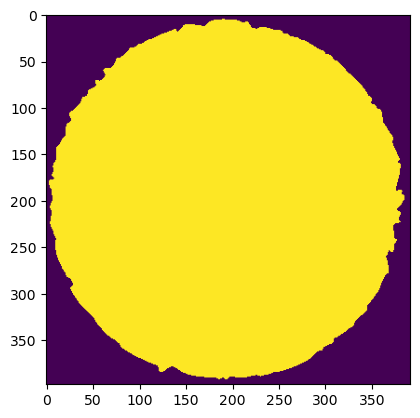

[2/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/kaurahiutale1min/capture/


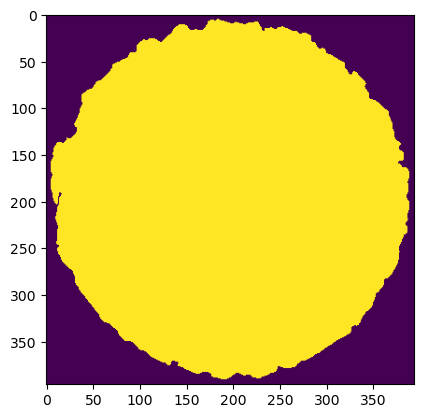

[3/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/kuivahiiva/capture/


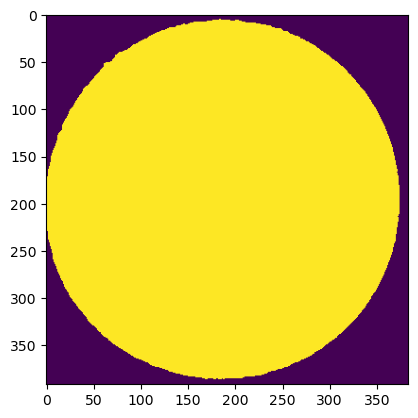

[4/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/kvinoa/capture/


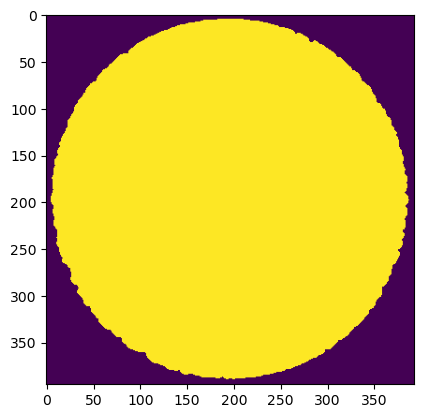

[5/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/ohrahiutale_kasittelematon/capture/


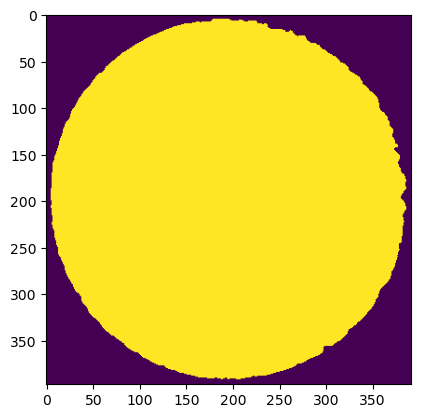

[6/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/psyllium/capture/


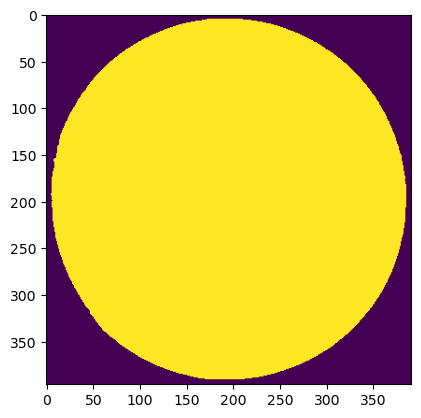

[7/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/puuroriisi/capture/


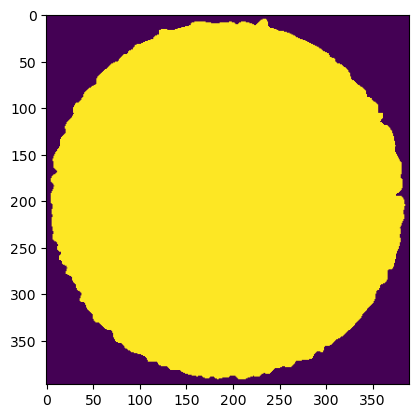

[8/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/rikottu_ohrasuurimo/capture/


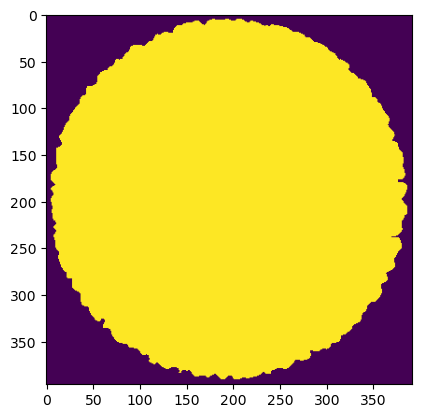

[9/23] /n/archive/labs/hsi-data/everyday_objects/kitchen/seesaminsiemen/capture/


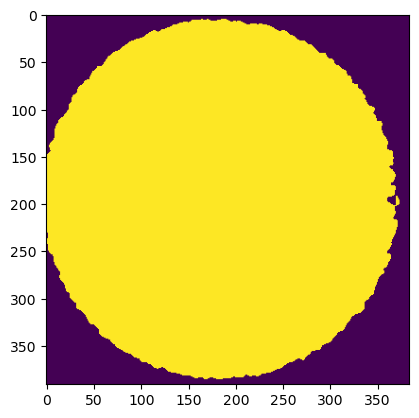

[10/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/durumvehna/capture/


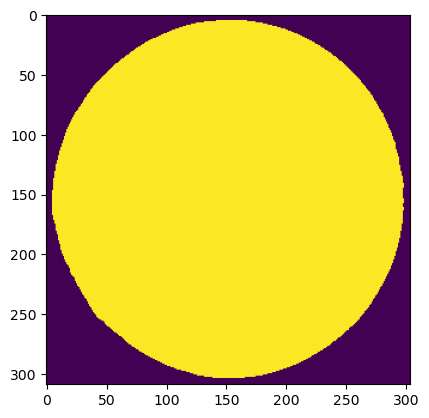

[11/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/jodioitu_suola/capture/


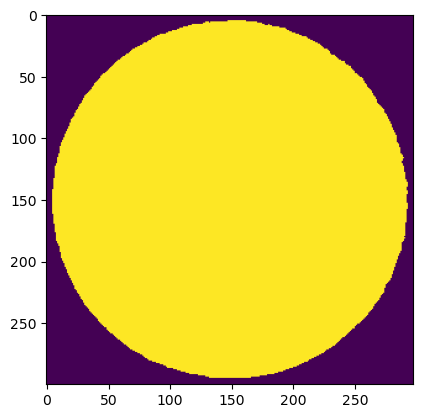

[12/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/karkea_vehnajauho/capture/


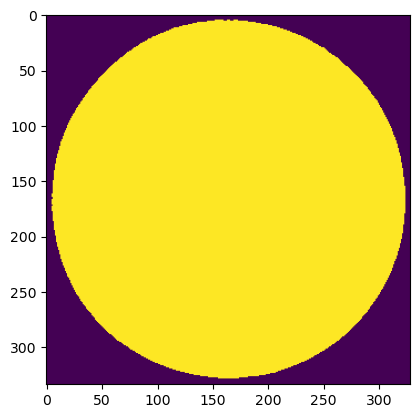

[13/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/kookoshiutale/capture/


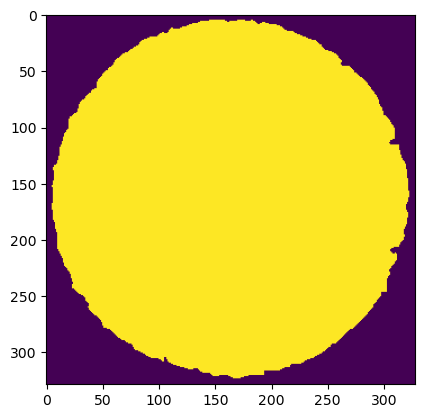

[14/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/leivinjauhe/capture/


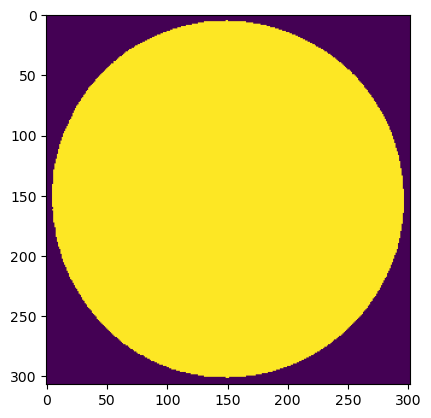

[15/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/maizena/capture/


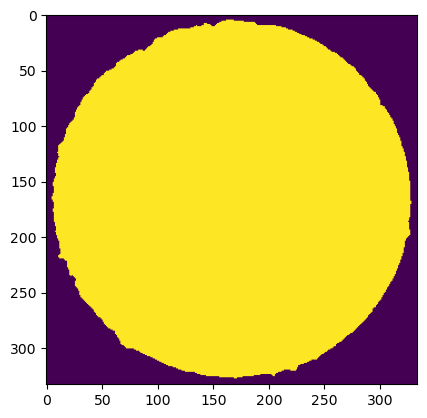

[16/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/merisuola/capture/


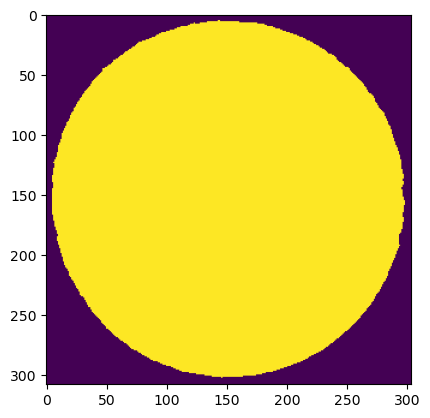

[17/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/perunajauho/capture/


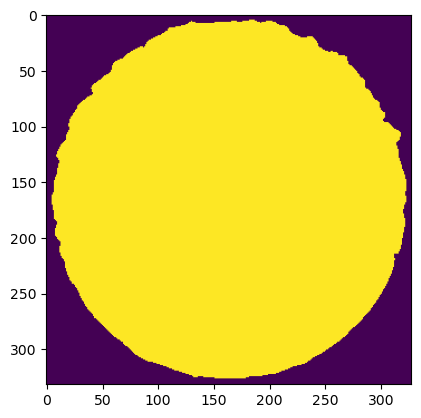

[18/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/puolikarkea_vehnajauho/capture/


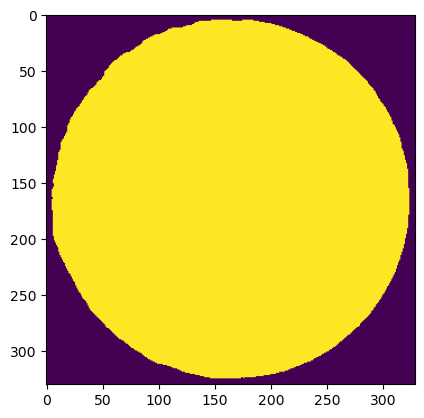

[19/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/raesokeri/capture/


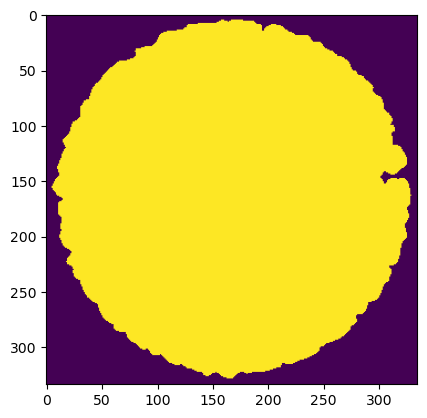

[20/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/sampylajauho/capture/


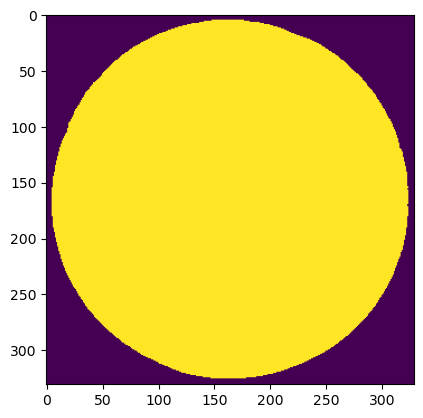

[21/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/sokeri/capture/


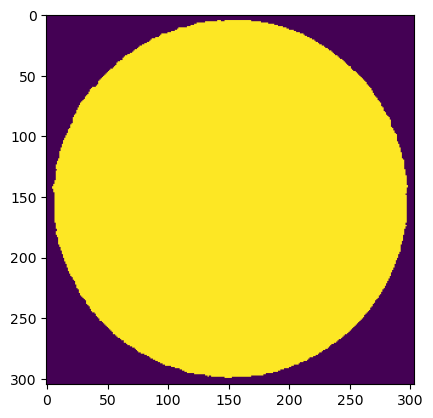

[22/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/sooda/capture/


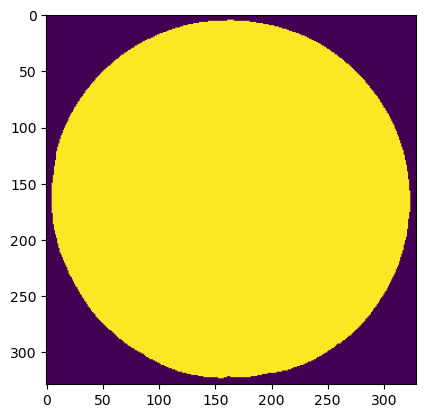

[23/23] /n/archive/labs/hsi-data/everyday_objects/kitchenday2/tomusokeri/capture/


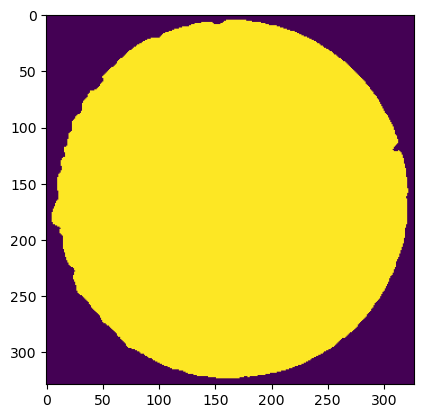


Processed 23/23 samples successfully.
There are 204 spectral bands in the cubes.


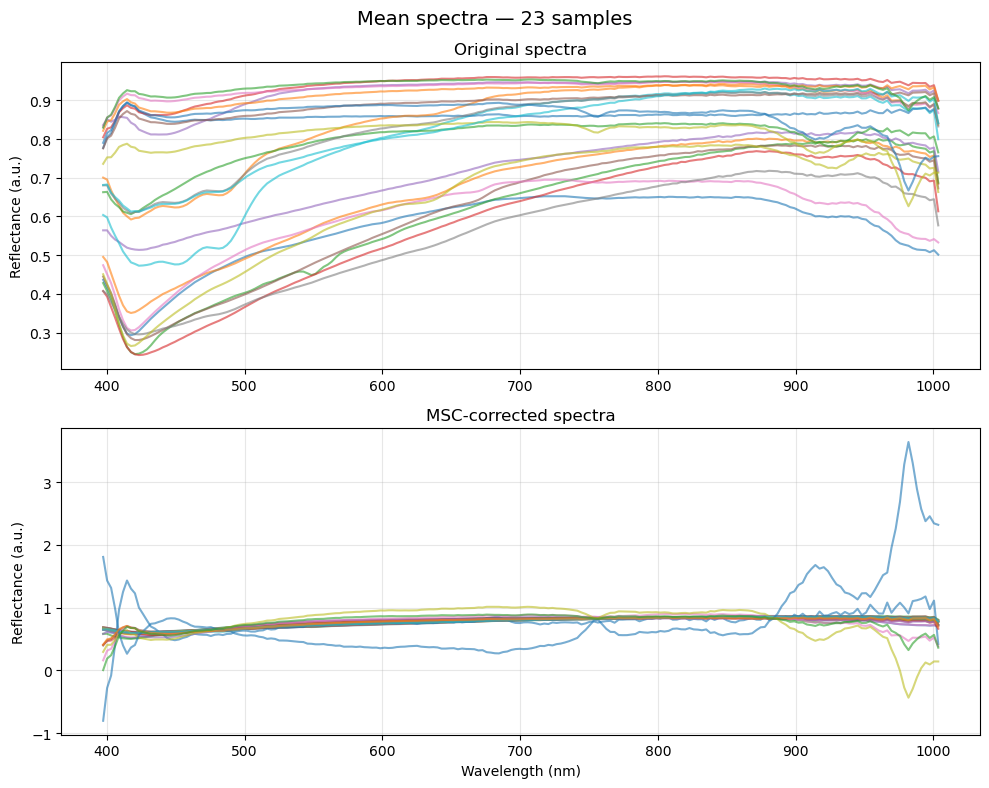

In [5]:
print(f"Found {len(folders)} sample(s)\n")

spectra, names = [], []
wavelengths = None

for i, folder in enumerate(folders, 1):
    print(f"[{i}/{len(folders)}] ", end="")
    capture = os.path.join(PATH, folder, "capture/")
    print(capture)

    if not os.path.isdir(capture):
        print(f"  Skipping {folder}: no 'capture' subfolder.")
        continue

    spec, wl = process_sample(PATH, folder, nums[i-1])
    if spec is not None:
        spectra.append(spec)
        names.append(folder)
        if wavelengths is None:
            wavelengths = wl

spectra_msc, ref_spectrum = multiplicative_scatter_correction(spectra)


print(f"\nProcessed {len(spectra)}/{len(folders)} samples successfully.")

print(f"There are {len(wavelengths)} spectral bands in the cubes.")

plot_spectra(wavelengths, spectra, spectra_msc, title=f"Mean spectra — {len(names)} samples", legends=folders)

In [7]:
os.listdir('/n/archive/labs/hsi-data/everyday_objects/kitchen/sekoite2/capture/')
(os.path.getsize('/n/archive/labs/hsi-data/everyday_objects/kitchen/sekoite2/capture/056.raw')/1024)/1024

102.0

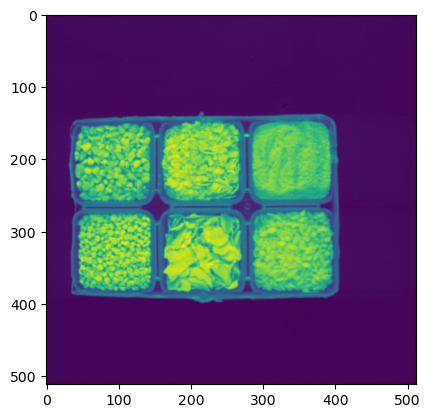

In [18]:
data_raw = spectral.envi.open('/n/archive/labs/hsi-data/everyday_objects/kitchen/sekoite2/capture/056.hdr')

cube_raw = np.array(data_raw.asarray())

'''
i = 1

for p in range(0, i):
    plt.subplot(1, i+1, p+1)
    plt.imshow(cube_raw[:,:,int(p*(204/i))])
    plt.axis('off')
'''
plt.imshow(cube_raw[:,:,150])
plt.show()

# Spectral analysis

Muuttujat:
- PATH : string
    - `everyday_objects`-datan polku
- spectra : list
    - Käytettyjen kuvien spektrit
- names : list
    - Käytettyjen kansioiden nimet
- wavelengths : list
    - Aallonpituudet
- spectra_msc : numpy.ndarray
    - MSC-käsitellyt spektrit
- ref_spectrum : numpy.ndarray

In [6]:
reflectance, wavelengths = load_and_compute_reflectance(PATH, folders[0], nums[0])
mask = create_sample_mask(reflectance)
segmented, roi_mask = segment_sample(reflectance, mask)
type(segmented)

/tmp/ipykernel_520884/3389343715.py:74: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_520884/3389343715.py:78: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


numpy.ndarray

In [25]:
samples = 40

names = []
pixels = []
averages = []

for n in range(len(folders)):
    cube, waves = load_and_compute_reflectance(PATH, folders[n], nums[n])
    mask = create_sample_mask(cube)
    segmented, roi_mask = segment_sample(cube, mask)
    i, j = np.nonzero(roi_mask)
    ix = np.random.choice(len(i), samples, replace=False)
    averages.append(segmented[i[ix], j[ix],:])
    pixels = [*pixels, *segmented[i[ix], j[ix],:]]
    names.extend([nums[n] for i in range(samples)])

pixels = np.array(pixels)
averages = [np.mean(a, axis=0) for a in averages]

/tmp/ipykernel_3292307/2087236125.py:74: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_3292307/2087236125.py:78: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    pixels, names, test_size=0.25, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = LogisticRegression(max_iter=1000)
#model = svm.SVC()
#model = SGDClassifier(loss="hinge", penalty="l2", max_iter=500)
#model = tree.DecisionTreeClassifier()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy: {round(accuracy,2)}")

accuracy: 0.85


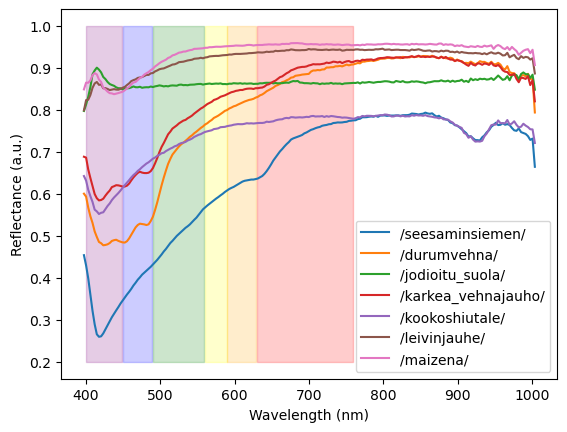

In [37]:
[plt.plot(wavelengths, a) for a in averages[8:-8]]
plt.fill_between(np.arange(400,450), 0.2, 1, color='purple', alpha=0.2)
plt.fill_between(np.arange(450,490), 0.2, 1, color='blue', alpha=0.2)
plt.fill_between(np.arange(490,560), 0.2, 1, color='green', alpha=0.2)
plt.fill_between(np.arange(560,590), 0.2, 1, color='yellow', alpha=0.2)
plt.fill_between(np.arange(590,630), 0.2, 1, color='orange', alpha=0.2)
plt.fill_between(np.arange(630,760), 0.2, 1, color='red', alpha=0.2)
legs = [s[s.index('/'):] for s in folders]
plt.legend(legs[8:-8])
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance (a.u.)')
plt.show()

In [52]:
mae = mean_absolute_error(y_true=y_test,y_pred=y_pred)
mse = mean_squared_error(y_true=y_test,y_pred=y_pred)

print("MAE:",mae)
print("MSE:",mse)

MAE: 5.8478260869565215
MSE: 105.94347826086957
